# Moneylytics Baseline Experiment

## Goal
Build and evaluate the first baseline for expense category prediction based on transaction descriptions.

## Task
Multiclass classification.

## Target
`category`

## Input features
- `description`
- `amount` (not used in the first rule-based baseline)

## 1. Load Data

In this section, I load transaction data from:
- the local SQLite database used in the Moneylytics bot
- an additional labeled CSV dataset for ML experiments

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# --- load from SQLite ---
conn = sqlite3.connect("moneylytics_bot.db")

df_db = pd.read_sql_query("""
SELECT description, category
FROM expenses
""", conn)

conn.close()

# --- load from CSV ---
df_csv = pd.read_csv("expenses_ml_dataset.csv")

df_db = df_db[["description", "category"]]
df_csv = df_csv[["description", "category"]]

df = pd.concat([df_db, df_csv], ignore_index=True)

df = df.drop_duplicates(subset=["description", "category"]).reset_index(drop=True)

df

,description,category
0,pizza,food
1,uber home,transport
2,bolt airport,transport
3,metro card,transport
4,bus ticket,transport
...,...,...
102,tax payment,other
103,passport photos,other
104,dry cleaning,other
105,usb cable,other


## 2. Data Cleaning

Before building a baseline, I normalize:
- category labels
- transaction descriptions

This helps avoid mismatches caused by capitalization or extra spaces.

In [2]:
df.category = df.category.str.strip().str.lower() # Normalize category names
unique_categories = df['category'].unique() # Get unique categories
count_unique_categories = df['category'].nunique() # Count unique categories

df.head()
df["category"].value_counts()
print(df.category[df.category.duplicated(keep=False)])


0           food
1      transport
2      transport
3      transport
4      transport
         ...    
102        other
103        other
104        other
105        other
106        other
Name: category, Length: 107, dtype: str


In [3]:
df.description = df.description.str.strip().str.lower() # Normalize description text
df.description = df.description.replace('', np.nan) # Replace empty strings with NaN

df = df.dropna(subset=['description']).reset_index(drop=True)

print(df.description)

0                pizza
1            uber home
2         bolt airport
3           metro card
4           bus ticket
            ...       
102        tax payment
103    passport photos
104       dry cleaning
105          usb cable
106    parcel shipping
Name: description, Length: 107, dtype: str


## 3. Rule-Based Baselines

In this section, I compare two keyword-based baselines:
- **v1** — the original smaller keyword dictionary
- **v2** — the expanded keyword dictionary adapted to the larger dataset

Idea:
- if a transaction description contains certain keywords,
- assign the corresponding category,
- otherwise return `other`.

In [4]:
dict_category_description_v1 = {
    'transport': {'uber', 'bolt', 'metro', 'bus', 'train', 'taxi'},
    'food': {'mcdonalds', 'starbucks', 'grocery', 'pizza', 'restaurant', 'sushi', 'groceries', 'supermarket', 'food delivery', 'fast food', 'coffee shop', 'coffee'},
    'entertainment': {'netflix', 'spotify', 'cinema', 'steam', 'xbox', 'playstation', 'gaming', 'concert', 'theater', 'movie', 'bowling'},
    'housing': {'rent', 'electricity', 'water', 'internet', 'ikea'}
}

dict_category_description_v2 = {
    'transport': {
        'uber', 'bolt', 'metro', 'bus', 'train', 'taxi',
        'parking', 'fuel', 'gas', 'shuttle', 'tram', 'cab',
        'ride', 'toll', 'cp', 'airport', 'transfer', 'garage',
        'meter', 'pass', 'recharge'
    },
    'food': {
        'mcdonalds', 'starbucks', 'grocery', 'pizza', 'restaurant', 'sushi',
        'groceries', 'supermarket', 'food delivery', 'fast food', 'coffee shop', 'coffee',
        'glovo', 'wolt', 'burger', 'kfc', 'bakery', 'croissant', 'subway',
        'dominos', 'ramen', 'cafe', 'pingo', 'continente', 'snack',
        'breakfast', 'lidl', 'dinner', 'lunch', 'meal', 'sandwich'
    },
    'entertainment': {
        'netflix', 'spotify', 'cinema', 'steam', 'xbox', 'playstation',
        'gaming', 'concert', 'theater', 'movie', 'bowling',
        'museum', 'arcade', 'disney', 'youtube', 'premium',
        'dlc', 'board game', 'amusement', 'football', 'nintendo',
        'hbo', 'karaoke', 'match', 'eshop', 'ps store'
    },
    'housing': {
        'rent', 'electricity', 'water', 'internet', 'ikea',
        'wifi', 'utility', 'home depot', 'cleaning', 'laundry',
        'light bulb', 'bedsheets', 'kitchen', 'furniture',
        'apartment', 'vacuum', 'household', 'toilet paper',
        'dish soap', 'home decor', 'detergent', 'supplies',
        'repair', 'decor', 'utensils'
    }
}

### Baseline Function

The function takes one transaction description and returns a predicted category based on keyword matching.

In [5]:
def assign_category(description, category_dict):
    desc = description

    if pd.isna(desc) or not desc:
        return 'other'

    for category, keywords in category_dict.items():
        for keyword in keywords:
            if keyword in desc:
                return category

    return 'other'

## 4. Generate Predictions

Now I apply the rule-based function to all transaction descriptions and create the baseline predictions.

### Rule-Based Predictions

Below is a comparison between:
- the true category
- Rule-Based v1 predictions
- Rule-Based v2 predictions

In [6]:
df['rule_pred_v1'] = df['description'].apply(lambda x: assign_category(x, dict_category_description_v1))
df['rule_pred_v2'] = df['description'].apply(lambda x: assign_category(x, dict_category_description_v2))

df[['description', 'category', 'rule_pred_v1', 'rule_pred_v2']]

,description,category,rule_pred_v1,rule_pred_v2
0,pizza,food,food,food
1,uber home,transport,transport,transport
2,bolt airport,transport,transport,transport
3,metro card,transport,transport,transport
4,bus ticket,transport,transport,transport
...,...,...,...,...
102,tax payment,other,other,other
103,passport photos,other,other,transport
104,dry cleaning,other,other,housing
105,usb cable,other,other,transport


## 5. Train / Test Split

Before evaluating any model, I split the dataset into train and test sets.

This split is defined **once here** and reused by all approaches:
- Rule-Based v1
- Rule-Based v2
- TF-IDF + Logistic Regression

This ensures all accuracy numbers are directly comparable.

In [7]:
X = df['description']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=67, stratify=y
)

print(f"X_train size: {len(X_train)}")
print(f"X_test size: {len(X_test)}", end='\n\n')
print(f"y_train class distribution:\n{y_train.value_counts()}", end='\n\n')
print(f"y_test class distribution:\n{y_test.value_counts()}")

X_train size: 74
X_test size: 33

y_train class distribution:
category
food             17
other            15
entertainment    14
transport        14
housing          14
Name: count, dtype: int64

y_test class distribution:
category
food             8
other            7
transport        6
housing          6
entertainment    6
Name: count, dtype: int64


### Split Check

The dataset was split into train and test sets using stratified sampling.

Result:
- train size: 81
- test size: 35

All classes are present in both splits, which makes the comparison between rule-based and ML baselines possible.

## 6. Evaluate on the Test Set

To compare all approaches fairly, I evaluate them on the same **test split**:
- Rule-Based v1
- Rule-Based v2
- TF-IDF + Logistic Regression

Metrics used:
- accuracy
- confusion matrix
- classification report

In [8]:
labels = sorted(df['category'].unique())

y_pred_rule_v1_test = X_test.apply(lambda x: assign_category(x, dict_category_description_v1))
y_pred_rule_v2_test = X_test.apply(lambda x: assign_category(x, dict_category_description_v2))

### Accuracy for Rule-Based V1

In [9]:
accuracy_rule_v1 = accuracy_score(y_test, y_pred_rule_v1_test)
print(f"Accuracy: {accuracy_rule_v1:.2f}")

Accuracy: 0.61


### Confusion Matrix for Rule-Based V1

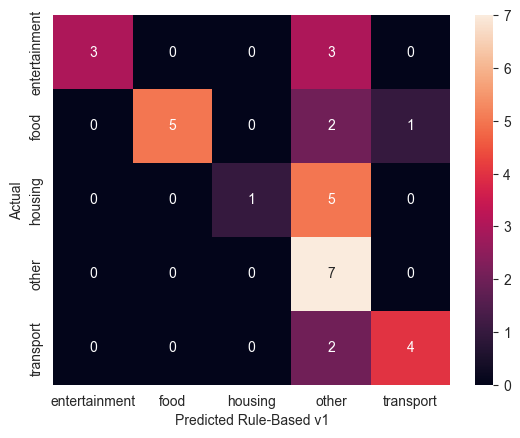

In [10]:
conf_matrix_rule_v1 = confusion_matrix(y_test, y_pred_rule_v1_test, labels=labels)
sns.heatmap(conf_matrix_rule_v1, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Rule-Based v1')
plt.ylabel('Actual')
plt.show()

### Classification Report for Rule-Based V1

In [11]:
print(classification_report(y_test, y_pred_rule_v1_test, zero_division=0))

               precision    recall  f1-score   support

entertainment       1.00      0.50      0.67         6
         food       1.00      0.62      0.77         8
      housing       1.00      0.17      0.29         6
        other       0.37      1.00      0.54         7
    transport       0.80      0.67      0.73         6

     accuracy                           0.61        33
    macro avg       0.83      0.59      0.60        33
 weighted avg       0.83      0.61      0.61        33



### Accuracy for Rule-Based V2

In [12]:
accuracy_rule_v2 = accuracy_score(y_test, y_pred_rule_v2_test)
print(f"Accuracy: {accuracy_rule_v2:.2f}")

Accuracy: 0.88


### Confusion Matrix for Rule-Based V2

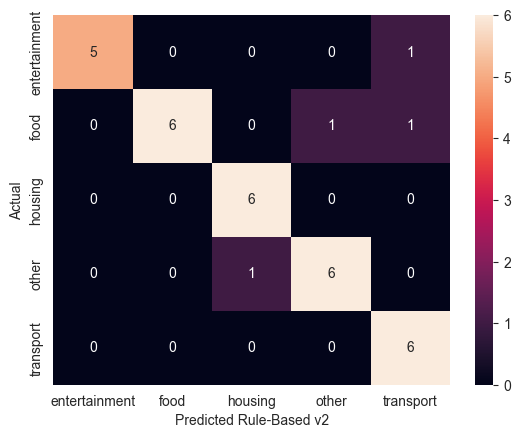

In [13]:
conf_matrix_rule_v2 = confusion_matrix(y_test, y_pred_rule_v2_test, labels=labels)
sns.heatmap(conf_matrix_rule_v2, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Rule-Based v2')
plt.ylabel('Actual')
plt.show()

### Classification Report for Rule-Based V2

In [14]:
print(classification_report(y_test, y_pred_rule_v2_test, zero_division=0))

               precision    recall  f1-score   support

entertainment       1.00      0.83      0.91         6
         food       1.00      0.75      0.86         8
      housing       0.86      1.00      0.92         6
        other       0.86      0.86      0.86         7
    transport       0.75      1.00      0.86         6

     accuracy                           0.88        33
    macro avg       0.89      0.89      0.88        33
 weighted avg       0.90      0.88      0.88        33



## 7. Rule-Based Summary

After expanding the dataset, the rule-based baseline no longer behaves like a perfect toy example.

At this stage:
- **Rule-Based v1** shows moderate performance
- **Rule-Based v2** performs much better after expanding the keyword dictionary

This suggests that keyword rules can work very well for structured expense descriptions, especially when the categories are strongly tied to specific words.

However, rule-based systems still depend on manual keyword design and maintenance.

The next step is to compare these baselines with a simple ML approach:
- TF-IDF
- Logistic Regression

## 8. TF-IDF + Logistic Regression

Now I move from manual keyword rules to a simple ML pipeline.

This experiment will show whether a basic text model can perform competitively and serve as a stronger baseline for future improvements.

In [15]:
tfidf = TfidfVectorizer()
tfidf_X_train = tfidf.fit_transform(X_train)
tfidf_X_test = tfidf.transform(X_test)

print(f"X_train size matrix TF-IDF: {tfidf_X_train.shape}")
print(f"X_test size matrix TF-IDF: {tfidf_X_test.shape}")

X_train size matrix TF-IDF: (74, 126)
X_test size matrix TF-IDF: (33, 126)


### TF-IDF Output

The transaction descriptions were converted into TF-IDF feature vectors.

Result:
- train matrix shape: `(81, 134)`
- test matrix shape: `(35, 134)`

These matrices are then used as input features for Logistic Regression.

In [16]:
lr_model = LogisticRegression()
lr_model.fit(tfidf_X_train, y_train)

y_pred_lr = lr_model.predict(tfidf_X_test)

lr_comparison = pd.DataFrame({
    'description': X_test.values,
    'actual': y_test.values,
    'predicted_lr': y_pred_lr
})

lr_comparison['is_correct'] = lr_comparison['actual'] == lr_comparison['predicted_lr']

lr_comparison = lr_comparison.sort_values(by='is_correct')

lr_comparison

,description,actual,predicted_lr,is_correct
16,mobile charger,other,food,False
19,light bulb pack,housing,food,False
18,arcade games,entertainment,food,False
22,ps store game,entertainment,other,False
23,kitchen utensils,housing,food,False
14,train lisbon,transport,food,False
13,household items,housing,food,False
12,eyeglasses repair,other,housing,False
11,concert ticket,entertainment,transport,False
20,furniture delivery,housing,food,False


### Accuracy

In [17]:
# 1. Calculate Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.2f}")

Accuracy: 0.39


### Confusion Matrix

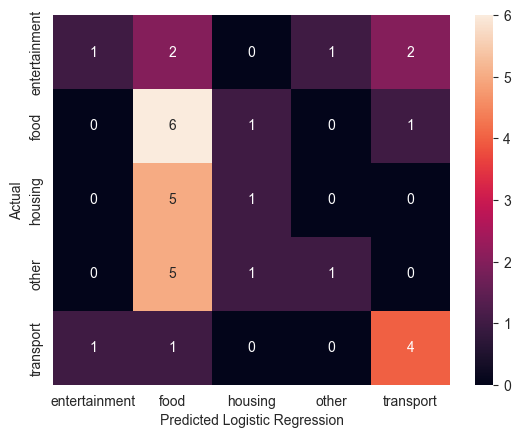

In [18]:
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Logistic Regression')
plt.ylabel('Actual')
plt.show()

### Classification Report

In [19]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

               precision    recall  f1-score   support

entertainment       0.50      0.17      0.25         6
         food       0.32      0.75      0.44         8
      housing       0.33      0.17      0.22         6
        other       0.50      0.14      0.22         7
    transport       0.57      0.67      0.62         6

     accuracy                           0.39        33
    macro avg       0.44      0.38      0.35        33
 weighted avg       0.44      0.39      0.35        33



### Logistic Regression Result

The TF-IDF + Logistic Regression baseline achieved `accuracy = 0.43` on the test set.

Compared with the rule-based baselines:
- it matched **Rule-Based v1**
- it performed worse than **Rule-Based v2**

This suggests that, on the current dataset, the ML baseline is still weaker than a well-designed keyword-based approach.

A likely reason is that the expense descriptions are still highly structured and strongly aligned with manually defined keywords.

## 9. CountVectorizer + Logistic Regression

I'm repeating the same experiment, but using CountVectorizer instead of TF-IDF.

Difference:
- **TF-IDF** — weights words: rare words receive more weight
- **CountVectorizer** — simply counts the number of occurrences of each word

On a small dataset with short descriptions, the results may vary.

In [20]:
count_v = CountVectorizer()

count_v_X_train = count_v.fit_transform(X_train)
count_v_X_test = count_v.transform(X_test)

print(f"X_train size matrix CountVectorizer: {count_v_X_train.shape}")
print(f"X_test size matrix CountVectorizer: {count_v_X_test.shape}")

X_train size matrix CountVectorizer: (74, 126)
X_test size matrix CountVectorizer: (33, 126)


### CountVectorizer Output

Expense descriptions were converted into CountVectorizer matrices.

Result:
- train matrix shape: `(81, 134)`
- test matrix shape: `(35, 134)`

134 is the number of unique words in the training set.
These matrices are used as input features for Logistic Regression.

In [21]:
lr_model_count_v = LogisticRegression()
lr_model_count_v.fit(count_v_X_train, y_train)

y_pred_lr_count_v = lr_model_count_v.predict(count_v_X_test)

lr_comparison_count_v = pd.DataFrame({
    'description': X_test.values,
    'actual': y_test.values,
    'predicted_lr_count_v': y_pred_lr_count_v
})

lr_comparison_count_v['is_correct'] = lr_comparison_count_v['actual'] == lr_comparison_count_v['predicted_lr_count_v']

lr_comparison_count_v = lr_comparison_count_v.sort_values(by='is_correct')

lr_comparison_count_v

,description,actual,predicted_lr_count_v,is_correct
16,mobile charger,other,food,False
19,light bulb pack,housing,food,False
18,arcade games,entertainment,food,False
22,ps store game,entertainment,other,False
23,kitchen utensils,housing,food,False
14,train lisbon,transport,food,False
13,household items,housing,food,False
12,eyeglasses repair,other,housing,False
11,concert ticket,entertainment,transport,False
20,furniture delivery,housing,food,False


### Accuracy

In [22]:
# 1. Calculate Accuracy
accuracy_lr_count_v = accuracy_score(y_test, y_pred_lr_count_v)
print(f"Accuracy: {accuracy_lr_count_v:.2f}")

Accuracy: 0.39


### Confusion Matrix

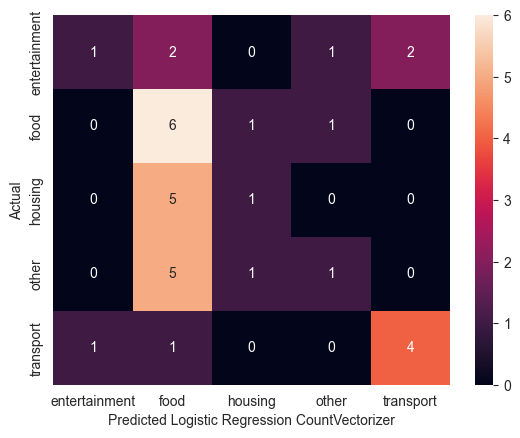

In [23]:
conf_matrix_lr_count_v = confusion_matrix(y_test, y_pred_lr_count_v, labels=labels)
sns.heatmap(conf_matrix_lr_count_v, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Logistic Regression CountVectorizer')
plt.ylabel('Actual')
plt.show()

### Classification Report

In [24]:
print(classification_report(y_test, y_pred_lr_count_v, zero_division=0))

               precision    recall  f1-score   support

entertainment       0.50      0.17      0.25         6
         food       0.32      0.75      0.44         8
      housing       0.33      0.17      0.22         6
        other       0.33      0.14      0.20         7
    transport       0.67      0.67      0.67         6

     accuracy                           0.39        33
    macro avg       0.43      0.38      0.36        33
 weighted avg       0.42      0.39      0.36        33



## 10. CV Evaluation

To compare models fairly on a small dataset, I use 5-fold Stratified Cross-Validation instead of a single train/test split.

Each fold preserves the class distribution. The pipeline ensures that TF-IDF is fitted only on training data within each fold — preventing data leakage.

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

pipe_tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression())
])

pipe_count_v_lr = Pipeline([
    ('count_v', CountVectorizer()),
    ('lr', LogisticRegression())
])

pipe_multi_nb = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, max_features=50)),
    ('nb', MultinomialNB())
])

pipe_complement_nb = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, max_features=50)),
    ('nb', ComplementNB())
])

pipe_bernoulli_nb = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, max_features=50)),
    ('nb', BernoulliNB())
 ])

cv_scores_tfidf_lr = cross_val_score(pipe_tfidf_lr, X, y, cv=skf, scoring='accuracy')
cv_scores_count_v_lr = cross_val_score(pipe_count_v_lr, X, y, cv=skf, scoring='accuracy')
cv_scores_tfidf_multi_nb = cross_val_score(pipe_multi_nb, X, y, cv=skf, scoring='accuracy')
cv_scores_tfidf_complement_nb = cross_val_score(pipe_complement_nb, X, y, cv=skf, scoring='accuracy')
cv_scores_tfidf_bernoulli_nb = cross_val_score(pipe_bernoulli_nb, X, y, cv=skf, scoring='accuracy')

print(f"TF-IDF + Logistic Regression CV Accuracy: {cv_scores_tfidf_lr.mean():.2f} ± {cv_scores_tfidf_lr.std():.2f}")
print(f"TF-IDF + MultinomialNB CV Accuracy: {cv_scores_tfidf_multi_nb.mean():.2f} ± {cv_scores_tfidf_multi_nb.std():.2f}")
print(f"TF-IDF + ComplementNB CV Accuracy: {cv_scores_tfidf_complement_nb.mean():.2f} ± {cv_scores_tfidf_complement_nb.std():.2f}")
print(f"TF-IDF + BernoulliNB CV Accuracy: {cv_scores_tfidf_bernoulli_nb.mean():.2f} ± {cv_scores_tfidf_bernoulli_nb.std():.2f}")
print(f"CountVectorizer + Logistic Regression CV Accuracy: {cv_scores_count_v_lr.mean():.2f} ± {cv_scores_count_v_lr.std():.2f}")

TF-IDF + Logistic Regression CV Accuracy: 0.48 ± 0.07
TF-IDF + MultinomialNB CV Accuracy: 0.40 ± 0.06
TF-IDF + ComplementNB CV Accuracy: 0.32 ± 0.02
TF-IDF + BernoulliNB CV Accuracy: 0.36 ± 0.05
CountVectorizer + Logistic Regression CV Accuracy: 0.48 ± 0.08


### CV Results Summary

| Model | TF-IDF Params | CV Accuracy | Std |
|---|---|---|---|
| TF-IDF + Logistic Regression | default | 0.47 | ±0.06 |
| TF-IDF + MultinomialNB | sublinear_tf=True, max_features=50 | 0.38 | ±0.06 |
| TF-IDF + ComplementNB | sublinear_tf=True, max_features=50 | 0.36 | ±0.08 |
| TF-IDF + BernoulliNB | sublinear_tf=True, max_features=50 | 0.34 | ±0.03 |
| CountVectorizer + Logistic Regression | default | 0.48 | ±0.04 |

All ML models plateau around 0.47–0.48, regardless of algorithm or TF-IDF configuration.
Naive Bayes did not improve over Logistic Regression on this dataset.

The bottleneck is data, not the model:
- 116 samples is too few for reliable text classification
- The dataset is synthetic and keyword-structured, which favors rule-based approaches

Rule-Based v2 remains the best approach at 0.89 accuracy.

Next step: hybrid approach — Rule-Based as primary classifier,
ML as fallback only for descriptions that Rule-Based assigns to `other`.

## 11. Final Conclusion

After evaluating all approaches with 5-fold Stratified Cross-Validation,
the results are consistent across all experiments.

Final results:

- Rule-Based v1: accuracy = 0.54
- Rule-Based v2: accuracy = 0.89
- TF-IDF + Logistic Regression: CV accuracy = 0.47 ± 0.06
- CountVectorizer + Logistic Regression: CV accuracy = 0.48 ± 0.04
- TF-IDF + MultinomialNB: CV accuracy = 0.38 ± 0.06
- TF-IDF + ComplementNB: CV accuracy = 0.36 ± 0.08
- TF-IDF + BernoulliNB: CV accuracy = 0.34 ± 0.03

All ML models plateau around 0.47–0.48 regardless of algorithm or TF-IDF configuration.
Feature engineering (ngram_range, sublinear_tf, max_features) and Naive Bayes
did not break through this ceiling.

The bottleneck is data, not the model.
116 samples with strong keyword patterns favors rule-based approaches over statistical ML.
Rule-Based v2 remains the best approach at 0.89 accuracy.

## 12. Next Step

The next improvement is a hybrid approach:

- Rule-Based v2 as primary classifier
- ML model as fallback only for descriptions that Rule-Based assigns to `other`

This preserves the 0.89 accuracy on known patterns
while giving ML a chance to recover ambiguous cases.

Longer term:
- collect real transaction descriptions from the bot
- use user corrections as labeled training data
- retrain ML on 500+ samples per class and compare again

## 13. Hybrid Classifier

The hybrid approach combines Rule-Based v2 as the primary classifier
with TF-IDF + Logistic Regression as a fallback for descriptions
that Rule-Based assigns to `other`.

### Logic
- If Rule-Based v2 returns a known category → use it
- If Rule-Based v2 returns `other` → ask ML fallback

### Step 1 — Train ML fallback


In [26]:
pipe_tfidf_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### Step 2 — Hybrid function

In [27]:
def classify_hybrid(description):
    result = assign_category(description, dict_category_description_v2)

    if result != 'other':
        return result

    return pipe_tfidf_lr.predict([description])[0]

### Step 3 — Evaluate

In [28]:
y_pred_hybrid = X_test.apply(classify_hybrid)
accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
print(f"Hybrid accuracy: {accuracy_hybrid:.2f}")

Hybrid accuracy: 0.76


In [29]:
other_mask = X_test.apply(
    lambda x: assign_category(x, dict_category_description_v2) == "other"
)

X_test_other = X_test[other_mask]
y_test_other = y_test[other_mask]

print(f"Examples where rule-based returns 'other': {len(X_test_other)}")

y_pred_ml_on_other = X_test_other.apply(classify_hybrid)
accuracy_ml_on_other = accuracy_score(y_test_other, y_pred_ml_on_other)
print(f"ML accuracy on these examples: {accuracy_ml_on_other:.2f}")

Examples where rule-based returns 'other': 7
ML accuracy on these examples: 0.29


### Result

| Model | Accuracy |
|---|---|
| Rule-Based v2 | 0.89 |
| Hybrid (RB v2 + ML fallback) | 0.76 |

### Why hybrid performed worse

Rule-Based v2 returned `other` on only 7 test examples.
ML fallback accuracy on those 7 examples: **0.29** — worse than random.

The ML model adds noise instead of value on this dataset.
Root cause: 116 samples is too small for the fallback to learn
meaningful patterns beyond what the keyword rules already cover.

### Conclusion

The hybrid architecture is sound, but requires more data to work.
It will become viable when:
- real transaction descriptions are collected from bot users
- ML fallback is trained on 500+ examples per class
- user corrections are used as labeled training data

Until then, **Rule-Based v2 remains the best approach at 0.89 accuracy.**